## 1. Title and Research Paper Reference

# QACO Research Paper Implementation

This executable notebook implements the methodology in Qiub *et al.*, **“A Novel Quantum Algorithm for Ant Colony Optimization (QACO)”**, arXiv:2403.00367v1 (February 2024). It first validates a self-contained 4-city TSP, then demonstrates a capacity-constrained 16-city hybrid.

Direct paper components are labeled **EXACT FROM PAPER**. Missing details are disclosed as **Implementation Assumption**, never presented as a paper fact.

## 2. Environment / Dependency Installation

The numerical implementation uses NumPy and Matplotlib. Pandas is used only for prettier tables and has a built-in text-table fallback, so it is not required. The following cell installs any missing core packages automatically. An optional Qiskit/Aer install command is included for users wanting to inspect a `QuantumCircuit`; it is not required for execution because the runnable reference measurement backend below is a NumPy state/probability simulator.

The original paper reports using the Yiwei Quantum Computing Simulation Platform. Qiskit/Aer is used here as a practical simulator and therefore does not constitute an exact reproduction of the original simulation environment.

In [1]:
import importlib.util
import subprocess
import sys

required_packages = ["numpy", "matplotlib"]
missing_packages = [p for p in required_packages if importlib.util.find_spec(p) is None]
if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
# Optional (uncomment only when an Aer backend is desired):
# subprocess.check_call([sys.executable, "-m", "pip", "install", "qiskit", "qiskit-aer"])
print("Core notebook dependencies ready:", required_packages)

Core notebook dependencies ready: ['numpy', 'matplotlib']


## 3. Imports

All imports used by later cells are collected here so the notebook has no hidden dependencies.

In [2]:
import math
import itertools
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

try:
    import pandas as pd
except ImportError:
    # Display-only fallback: notebook algorithms do not depend on pandas.
    class _TextFrame:
        def __init__(self, data=None, columns=None): self.data, self.columns = data, columns
        def round(self, *args, **kwargs): return self
        def __repr__(self): return f"Table(columns={self.columns}, rows={self.data})"
    class _PD: DataFrame = _TextFrame
    pd = _PD()

plt.style.use("seaborn-v0_8-whitegrid")

## 4. Configuration

Paper-specified values: 9 total qubits for four cities; 2 path qubits per city; one ancilla; initial rotation angle π/2; infeasible random repair for the first 10 iterations; and mutation angles at invariant counts 5, 10, and 15. The paper does not specify population/shots, iteration counts, a seed, route conventions, pool capacity, ACO evaporation, or pheromone initialization. Those are **Implementation Assumptions** below and are deliberately configurable.

In [3]:
SEED = 20260903
RNG = np.random.default_rng(SEED)

CONFIG = {
    "available_qubits": 9,
    "ancilla_qubits": 1,
    "initial_rotation_angle": np.pi / 2,  # EXACT FROM PAPER
    "random_repair_iterations": 10,       # EXACT FROM PAPER
    "mutation_schedule": {5: np.pi/6, 10: np.pi/4, 15: np.pi/2}, # EXACT FROM PAPER
    "qaco_iterations_4city": 70,          # Implementation Assumption
    "qaco_iterations_cluster": 45,        # Implementation Assumption
    "qaco_shots": 20,                     # Implementation Assumption
    "solution_pool_size": 24,              # Implementation Assumption
    "rotation_scale": 1.0,                 # Implementation Assumption
    "aco_ants": 6,                         # paper uses 6 ants for Ulysses-16
    "aco_iterations_4city": 70,            # Implementation Assumption
    "aco_iterations_16city": 180,          # Implementation Assumption
    "aco_alpha": 4.0,                      # paper's pheromone factor for Ulysses-16
    "aco_beta": 2.0,                       # paper's distance factor for Ulysses-16
    "aco_rho": 0.35,                       # Implementation Assumption
    "aco_q": 1.0,                          # Implementation Assumption
}
print(CONFIG)

{'available_qubits': 9, 'ancilla_qubits': 1, 'initial_rotation_angle': 1.5707963267948966, 'random_repair_iterations': 10, 'mutation_schedule': {5: 0.5235987755982988, 10: 0.7853981633974483, 15: 1.5707963267948966}, 'qaco_iterations_4city': 70, 'qaco_iterations_cluster': 45, 'qaco_shots': 20, 'solution_pool_size': 24, 'rotation_scale': 1.0, 'aco_ants': 6, 'aco_iterations_4city': 70, 'aco_iterations_16city': 180, 'aco_alpha': 4.0, 'aco_beta': 2.0, 'aco_rho': 0.35, 'aco_q': 1.0}


## 5. TSP Utility Functions

These utilities establish a single closed-tour convention: routes begin and end at `start_city`, while the interior contains every city exactly once. They are standard implementation infrastructure, not specified by the paper.

In [4]:
def euclidean_distance_matrix(coords):
    coords = np.asarray(coords, dtype=float)
    return np.sqrt(((coords[:, None, :] - coords[None, :, :]) ** 2).sum(axis=2))

def route_distance(route, D):
    return float(sum(D[route[i], route[i+1]] for i in range(len(route)-1)))

def is_valid_tour(route, n, start_city=0):
    return (len(route) == n + 1 and route[0] == start_city and route[-1] == start_city
            and set(route[:-1]) == set(range(n)) and len(set(route[:-1])) == n)

def validate_tour(route, D, start_city=0):
    n = len(D)
    assert is_valid_tour(route, n, start_city), f"Invalid TSP tour: {route}"
    distance = route_distance(route, D)
    assert np.isfinite(distance) and distance >= 0
    return distance

def random_tour(n, rng, start_city=0):
    remaining = [c for c in range(n) if c != start_city]
    rng.shuffle(remaining)
    return [start_city] + remaining + [start_city]

def plot_route(coords, route, title, ax=None):
    if ax is None: _, ax = plt.subplots(figsize=(5, 4))
    pts = np.asarray(coords)
    ax.scatter(pts[:,0], pts[:,1], s=55, zorder=3)
    for i, (x, y) in enumerate(pts): ax.annotate(str(i), (x, y), xytext=(4, 4), textcoords="offset points")
    ordered = pts[np.array(route)]
    ax.plot(ordered[:,0], ordered[:,1], '-o', alpha=.8)
    ax.set_title(title); ax.set_aspect('equal', adjustable='box')
    return ax

## 6. Dataset / Coordinate Definitions

The paper names Ulysses-16, bayg-29, and a random 64-point set but does not print their coordinates. It also does not supply a 4-city validation instance. Therefore the explicit 4-city square and 16-city coordinates below are **Implementation Assumptions** used only for reproducible validation; they are not claimed to be paper datasets.

In [5]:
coords_4 = np.array([[0., 0.], [1., 0.], [1., 1.], [0., 1.]])
# Explicit deterministic 16-city coordinate set for the hybrid demonstration.
coords_16 = np.array([
    [0.0,0.0],[1.2,0.1],[2.1,0.2],[3.1,0.0],
    [0.2,1.3],[1.0,1.1],[2.2,1.4],[3.3,1.2],
    [0.0,2.5],[1.3,2.3],[2.1,2.6],[3.2,2.4],
    [0.2,3.5],[1.1,3.7],[2.4,3.6],[3.3,3.8]
])
coords = coords_4  # required self-contained 4-city experiment alias
print("4-city coordinates:\n", coords_4)
print("16-city coordinate count:", len(coords_16))

4-city coordinates:
 [[0. 0.]
 [1. 0.]
 [1. 1.]
 [0. 1.]]
16-city coordinate count: 16


## 7. Distance Matrix Construction

Coordinates are defined before matrices, preventing hidden ordering dependencies. Euclidean distance is an implementation choice because the paper does not state the metric for its visual examples.

In [6]:
D = euclidean_distance_matrix(coords)
D_4 = D
D_16 = euclidean_distance_matrix(coords_16)
assert D_4.shape == (4, 4) and D_16.shape == (16, 16)
pd.DataFrame(D_4).round(3)

Table(columns=None, rows=[[0.         1.         1.41421356 1.        ]
 [1.         0.         1.         1.41421356]
 [1.41421356 1.         0.         1.        ]
 [1.         1.41421356 1.         0.        ]])

## 8. Binary City Encoding

**EXACT FROM PAPER (4-city case):** city identifiers are binary encoded with two qubits per city, giving eight path qubits plus q0 ancilla = nine qubits. The paper example says q10/q11 encodes path 2 as `10`; this notebook uses conventional MSB-first binary (`2 -> 10`). **Implementation Assumption:** larger clusters generalize to `ceil(log2(n))` bits per city.

In [7]:
def bits_per_city(n_cities):
    return max(1, math.ceil(math.log2(n_cities)))

def city_to_bits(city, width):
    return np.array([int(x) for x in format(int(city), f"0{width}b")], dtype=np.int8)

def encode_route(route, n_cities, include_return=False):
    width = bits_per_city(n_cities)
    cities = route if include_return else route[:-1]
    return np.concatenate([city_to_bits(city, width) for city in cities])

def decode_bits_to_cities(bits, n_cities, positions=None):
    width = bits_per_city(n_cities)
    positions = positions or n_cities
    bits = np.asarray(bits, dtype=int)
    if len(bits) != positions * width: raise ValueError("Incorrect path-bit length")
    values = [int(''.join(map(str, bits[i*width:(i+1)*width])), 2) for i in range(positions)]
    return values

def decode_measurement(path_bits, n_cities, start_city=0):
    cities = decode_bits_to_cities(path_bits, n_cities)
    # Raw circuit is infeasible unless each city occurs exactly once and start is first.
    feasible = len(set(cities)) == n_cities and set(cities) == set(range(n_cities)) and cities[0] == start_city
    return ([*cities, start_city] if feasible else None), feasible

assert np.array_equal(city_to_bits(2, 2), np.array([1, 0]))
print("4-city route [0,2,1,3,0] ->", encode_route([0,2,1,3,0], 4).tolist())

4-city route [0,2,1,3,0] -> [0, 0, 1, 0, 0, 1, 1, 1]


## 9. Hamming Distance Utilities

**EXACT FROM PAPER:** after iteration 10, infeasible paths are related to solution-pool paths through Hamming distance and selected with probability inversely proportional to distance (Eq. 7). The zero-distance guard below is an **Implementation Assumption** necessary for safe numerical sampling: exact binary matches receive a dominant finite weight.

In [8]:
def hamming_distance(a, b):
    a, b = np.asarray(a, dtype=np.int8), np.asarray(b, dtype=np.int8)
    if a.shape != b.shape: raise ValueError("Hamming inputs must have equal shape")
    return int(np.count_nonzero(a != b))

def inverse_hamming_probabilities(infeasible_bits, solution_pool, n_cities):
    if not solution_pool: return np.array([]), np.array([])
    target = np.asarray(infeasible_bits, dtype=np.int8)
    encodings = np.array([encode_route(r, n_cities) for r in solution_pool])
    distances = np.array([hamming_distance(target, e) for e in encodings], dtype=float)
    weights = 1.0 / np.maximum(distances, 1e-12) # safe zero-distance policy
    return distances, weights / weights.sum()

def select_from_pool(infeasible_bits, solution_pool, n_cities, rng):
    distances, probabilities = inverse_hamming_probabilities(infeasible_bits, solution_pool, n_cities)
    if len(probabilities) == 0: return None, distances, probabilities
    index = int(rng.choice(len(solution_pool), p=probabilities))
    return solution_pool[index].copy(), distances, probabilities

## 10. QACO Rotation-Angle Table

This is **EXACT FROM PAPER, Table 2**. `True` means the printed condition `f(x) > f(b)`; for a minimization TSP we evaluate it as `current_distance > global_best_distance`. The paper does not specify accumulated-angle clipping; we wrap angles modulo 2π as an **Implementation Assumption** for a stable runnable simulator.

In [9]:
ROTATION_TABLE = {
    (0, 0, True): -0.01, (0, 0, False): 0.04,
    (0, 1, True): -0.05, (0, 1, False): 0.07,
    (1, 0, True):  0.05, (1, 0, False): -0.07,
    (1, 1, True):  0.01, (1, 1, False): -0.04,
}
rotation_table_display = pd.DataFrame([
    {"current solution bit xi": x, "best solution bit bi": b, "f(x) > f(b)": better, "rotation angle": angle}
    for (x,b,better), angle in ROTATION_TABLE.items()
])
display(rotation_table_display)

def rotation_deltas(current_bits, best_bits, current_fitness, best_fitness):
    worse_than_best = bool(current_fitness > best_fitness)
    return np.array([ROTATION_TABLE[(int(x), int(b), worse_than_best)]
                     for x, b in zip(current_bits, best_bits)], dtype=float)

Table(columns=None, rows=[{'current solution bit xi': 0, 'best solution bit bi': 0, 'f(x) > f(b)': True, 'rotation angle': -0.01}, {'current solution bit xi': 0, 'best solution bit bi': 0, 'f(x) > f(b)': False, 'rotation angle': 0.04}, {'current solution bit xi': 0, 'best solution bit bi': 1, 'f(x) > f(b)': True, 'rotation angle': -0.05}, {'current solution bit xi': 0, 'best solution bit bi': 1, 'f(x) > f(b)': False, 'rotation angle': 0.07}, {'current solution bit xi': 1, 'best solution bit bi': 0, 'f(x) > f(b)': True, 'rotation angle': 0.05}, {'current solution bit xi': 1, 'best solution bit bi': 0, 'f(x) > f(b)': False, 'rotation angle': -0.07}, {'current solution bit xi': 1, 'best solution bit bi': 1, 'f(x) > f(b)': True, 'rotation angle': 0.01}, {'current solution bit xi': 1, 'best solution bit bi': 1, 'f(x) > f(b)': False, 'rotation angle': -0.04}])

## 11. Quantum Circuit Construction

The paper’s Figure 2 visibly initializes q0 and q10-q17 with Ry(π/2), shows ancilla-controlled operations, and measurements, but does not specify a machine-readable or unambiguous full gate sequence (control/target connectivity and later rotation updates are not recoverable exactly). **IMPLEMENTATION ASSUMPTION — QUANTUM CIRCUIT:** path qubits are independent Ry-prepared qubits, updated by Table 2 rotations; the ancilla probability is prepared by Ry(mutation angle), then conditionally mutates one path bit. This implements the described roles rather than claiming an exact reconstruction. `build_qiskit_circuit` is optional and only called if Qiskit is installed.

In [10]:
def build_qiskit_circuit(path_angles, ancilla_angle=0.0):
    """Optional Figure-2-inspired circuit representation; returns None without Qiskit."""
    try:
        from qiskit import QuantumCircuit
    except ImportError:
        return None
    qc = QuantumCircuit(len(path_angles) + 1, len(path_angles) + 1)
    qc.ry(ancilla_angle, 0)
    for i, angle in enumerate(path_angles, start=1): qc.ry(float(angle), i)
    # Assumption: ancilla controls a bit flip on the first path qubit; measurement is explicit.
    if abs(ancilla_angle) > 0: qc.cx(0, 1)
    qc.measure(range(len(path_angles)+1), range(len(path_angles)+1))
    return qc

def initialize_quantum_state(n_cities):
    return np.full(n_cities * bits_per_city(n_cities), CONFIG["initial_rotation_angle"], dtype=float)

def qubit_probability_one(angle):
    return np.sin(angle / 2.0) ** 2

def construct_quantum_circuit(path_angles, ancilla_angle):
    return {"path_angles": np.asarray(path_angles, float).copy(), "ancilla_angle": float(ancilla_angle),
            "n_qubits": len(path_angles) + CONFIG["ancilla_qubits"]}

## 12. Quantum Measurement and Candidate Generation

Measurement is statistical, as stated by the paper. This NumPy backend samples the Born probability of each Ry-prepared qubit. Its independent-qubit factorization is an **Implementation Assumption** caused by the unavailable exact Figure 2 gate topology. Raw decoded paths are deliberately allowed to be infeasible so that the paper’s examination module is exercised.

In [11]:
def measure_quantum_circuit(circuit, rng):
    probs = np.clip(qubit_probability_one(circuit["path_angles"]), 0, 1)
    path_bits = rng.binomial(1, probs).astype(np.int8)
    p_ancilla = float(np.clip(qubit_probability_one(circuit["ancilla_angle"]), 0, 1))
    ancilla = int(rng.random() < p_ancilla)
    if ancilla and len(path_bits): # ancilla-controlled mutation interpretation
        path_bits[int(rng.integers(len(path_bits)))] ^= 1
    return path_bits, ancilla

def generate_quantum_candidates(path_angles, ancilla_angle, shots, n_cities, rng):
    circuit = construct_quantum_circuit(path_angles, ancilla_angle)
    records = []
    for _ in range(shots):
        bits, ancilla = measure_quantum_circuit(circuit, rng)
        route, feasible = decode_measurement(bits, n_cities)
        records.append({"bits": bits, "route": route, "feasible": feasible, "ancilla": ancilla})
    return records

## 13. Infeasible-Solution Handling

**EXACT FROM PAPER:** infeasible samples receive a random feasible path in the first 10 iterations; after that they select a solution-pool path using Eq. 7 inverse-Hamming probabilities. The paper does not state the pool’s retention rule; retaining the best unique routes is an **Implementation Assumption**. Each returned candidate is asserted valid.

In [12]:
def maintain_solution_pool(pool, route, D, maximum):
    key = tuple(route)
    unique = {tuple(r): r for r in pool}
    unique[key] = route.copy()
    ordered = sorted(unique.values(), key=lambda r: route_distance(r, D))
    return [r.copy() for r in ordered[:maximum]]

def handle_infeasible_solution(bits, iteration, pool, n_cities, D, rng, diagnostics):
    diagnostics["infeasible_candidates"] += 1
    if iteration < CONFIG["random_repair_iterations"] or not pool:
        route = random_tour(n_cities, rng)
        diagnostics["random_repairs"] += 1
    else:
        route, distances, probabilities = select_from_pool(bits, pool, n_cities, rng)
        diagnostics["hamming_repairs"] += 1
        diagnostics["last_hamming_distances"] = distances.tolist()
        diagnostics["last_hamming_probabilities"] = probabilities.tolist()
    assert is_valid_tour(route, n_cities)
    return route

## 14. Mutation / Ancilla Mechanism

**EXACT FROM PAPER:** if the global best is invariant for 5, 10, or 15 iterations, ancilla Ry angles are π/6, π/4, π/2 respectively; beyond 15, mutation probability returns to zero. **Implementation Assumption:** use each angle only at its matching stagnation count (rather than keeping a prior angle across an interval), and implement mutation as an ancilla-conditioned random path-bit flip.

In [13]:
def ancilla_mutation_angle(invariant_iterations):
    if invariant_iterations > 15: return 0.0
    return float(CONFIG["mutation_schedule"].get(invariant_iterations, 0.0))

def mutation_probability(angle):
    return float(qubit_probability_one(angle))

for s in [0, 5, 10, 15, 16]:
    a = ancilla_mutation_angle(s)
    print(f"invariant={s:2d}: angle={a:.4f}, P(ancilla=1)={mutation_probability(a):.4f}")

invariant= 0: angle=0.0000, P(ancilla=1)=0.0000
invariant= 5: angle=0.5236, P(ancilla=1)=0.0670
invariant=10: angle=0.7854, P(ancilla=1)=0.1464
invariant=15: angle=1.5708, P(ancilla=1)=0.5000
invariant=16: angle=0.0000, P(ancilla=1)=0.0000


## 15. QACO Algorithm

This joins the paper’s specified initialization, rotation table, statistical candidate generation, global-best comparison, infeasibility rule, solution pool, and ancilla schedule. Pool updates and the representative current candidate used for rotation are **Implementation Assumptions**, because the paper’s Step 5 lacks pseudocode. Fitness is tour distance (lower is better).

In [14]:
def qaco_tsp(D, iterations, rng, shots=None, label="QACO"):
    n = len(D); shots = shots or CONFIG["qaco_shots"]
    path_angles = initialize_quantum_state(n)
    initial = random_tour(n, rng); global_best = initial.copy(); global_distance = route_distance(initial, D)
    pool = [initial.copy()]; invariant = 0; convergence = []; events = []
    diagnostics = {"feasible_candidates": 0, "infeasible_candidates": 0, "random_repairs": 0, "hamming_repairs": 0,
                   "mutation_activations": [], "best_updates": 0, "last_hamming_distances": [], "last_hamming_probabilities": []}
    for iteration in range(iterations):
        angle = ancilla_mutation_angle(invariant)
        if angle > 0:
            diagnostics["mutation_activations"].append((iteration, invariant, angle, mutation_probability(angle)))
        records = generate_quantum_candidates(path_angles, angle, shots, n, rng)
        candidates = []
        for rec in records:
            if rec["feasible"]:
                route = rec["route"]; diagnostics["feasible_candidates"] += 1
            else:
                route = handle_infeasible_solution(rec["bits"], iteration, pool, n, D, rng, diagnostics)
            candidates.append((route, route_distance(route, D), rec["bits"]))
        current_route, current_distance, current_bits = min(candidates, key=lambda x: x[1])
        improved = current_distance < global_distance - 1e-12
        if improved:
            global_best, global_distance, invariant = current_route.copy(), current_distance, 0
            diagnostics["best_updates"] += 1; events.append((iteration, global_distance))
        else:
            invariant += 1
        pool = maintain_solution_pool(pool, current_route, D, CONFIG["solution_pool_size"])
        best_bits = encode_route(global_best, n)
        path_angles = np.mod(path_angles + CONFIG["rotation_scale"] * rotation_deltas(current_bits, best_bits, current_distance, global_distance), 2*np.pi)
        convergence.append(global_distance)
    assert is_valid_tour(global_best, n)
    return {"label": label, "route": global_best, "distance": global_distance, "convergence": convergence,
            "diagnostics": diagnostics, "pool": pool, "final_angles": path_angles}

print("QACO implementation ready.")

QACO implementation ready.


## 16. Classical ACO Baseline

The baseline follows the paper’s Section 3 probabilistic pheromone/heuristic description. Its Ulysses-16 comparison used six ants, pheromone factor 4, distance factor 2, and 1000 iterations; the notebook uses the documented factors and six ants but shorter runs for an interactive demonstration. Evaporation/deposit details are **Implementation Assumptions** because they are not specified.

In [15]:
def aco_tsp(D, iterations, rng, ants=None, alpha=None, beta=None, rho=None, q=None):
    n = len(D); ants = ants or CONFIG["aco_ants"]; alpha = alpha or CONFIG["aco_alpha"]; beta = beta or CONFIG["aco_beta"]
    rho = rho or CONFIG["aco_rho"]; q = q or CONFIG["aco_q"]
    pheromone = np.ones((n,n), dtype=float); heuristic = 1.0 / (D + np.eye(n))
    global_best = None; global_distance = float("inf"); convergence = []
    for _ in range(iterations):
        tours = []
        for _ant in range(ants):
            route = [0]; unvisited = set(range(1,n))
            while unvisited:
                cur = route[-1]; choices = np.array(sorted(unvisited))
                weights = (pheromone[cur, choices] ** alpha) * (heuristic[cur, choices] ** beta)
                weights /= weights.sum()
                nxt = int(rng.choice(choices, p=weights)); route.append(nxt); unvisited.remove(nxt)
            route.append(0); dist = route_distance(route, D); tours.append((route, dist))
            if dist < global_distance: global_best, global_distance = route.copy(), dist
        pheromone *= (1-rho)
        for route, dist in tours:
            deposit = q / dist
            for i in range(n): pheromone[route[i], route[i+1]] += deposit; pheromone[route[i+1], route[i]] += deposit
        convergence.append(global_distance)
    assert is_valid_tour(global_best, n)
    return {"label": "ACO", "route": global_best, "distance": global_distance, "convergence": convergence}

print("Classical ACO baseline ready.")

Classical ACO baseline ready.


## 17. Exact Brute-Force Solver for Small TSPs

This exact enumerator is standard validation infrastructure, not a paper component. It is intentionally used only on the four-city problem.

In [16]:
def brute_force_tsp(D, start_city=0):
    n = len(D); best_route, best_distance = None, float("inf")
    for perm in itertools.permutations([c for c in range(n) if c != start_city]):
        route = [start_city, *perm, start_city]; distance = route_distance(route, D)
        if distance < best_distance: best_route, best_distance = route, distance
    assert is_valid_tour(best_route, n, start_city)
    return best_route, best_distance

## 18. 4-City Validation Experiment

This executes the required self-contained ordering: coordinates and D already exist; now exact ground truth, QACO, and ACO are executed with independently seeded reproducible generators.

In [17]:
exact_route_4, exact_distance_4 = brute_force_tsp(D_4)
qaco_4 = qaco_tsp(D_4, CONFIG["qaco_iterations_4city"], np.random.default_rng(SEED + 1), label="QACO (4-city)")
aco_4 = aco_tsp(D_4, CONFIG["aco_iterations_4city"], np.random.default_rng(SEED + 2))
for result in [qaco_4, aco_4]: validate_tour(result["route"], D_4)
print("Exact:", exact_route_4, exact_distance_4)
print("QACO:", qaco_4["route"], qaco_4["distance"])
print("ACO: ", aco_4["route"], aco_4["distance"])

Exact: [0, 1, 2, 3, 0] 4.0
QACO: [0, 3, 2, 1, 0] 4.0
ACO:  [0, 1, 2, 3, 0] 4.0


## 19. QACO vs ACO vs Exact Optimum

Distances, feasibility, and gaps are calculated from actual results. No outcome is claimed optimal without the brute-force check.

In [18]:
def optimality_gap(value, optimum): return 100 * (value - optimum) / optimum
comparison_4 = pd.DataFrame([
    ["Exact", exact_route_4, exact_distance_4, "Yes", 0.0],
    ["QACO", qaco_4["route"], qaco_4["distance"], "Yes" if is_valid_tour(qaco_4["route"],4) else "No", optimality_gap(qaco_4["distance"], exact_distance_4)],
    ["ACO", aco_4["route"], aco_4["distance"], "Yes" if is_valid_tour(aco_4["route"],4) else "No", optimality_gap(aco_4["distance"], exact_distance_4)],
], columns=["Method", "Route", "Distance", "Feasible", "Optimality Gap (%)"])
display(comparison_4.round({"Distance":4, "Optimality Gap (%)":2}))

Table(columns=['Method', 'Route', 'Distance', 'Feasible', 'Optimality Gap (%)'], rows=[['Exact', [0, 1, 2, 3, 0], 4.0, 'Yes', 0.0], ['QACO', [0, 3, 2, 1, 0], 4.0, 'Yes', 0.0], ['ACO', [0, 1, 2, 3, 0], 4.0, 'Yes', 0.0]])

## 20. Convergence Visualization

Best-so-far values are collected during execution, not hard-coded. Route plots complement the requested convergence comparison.

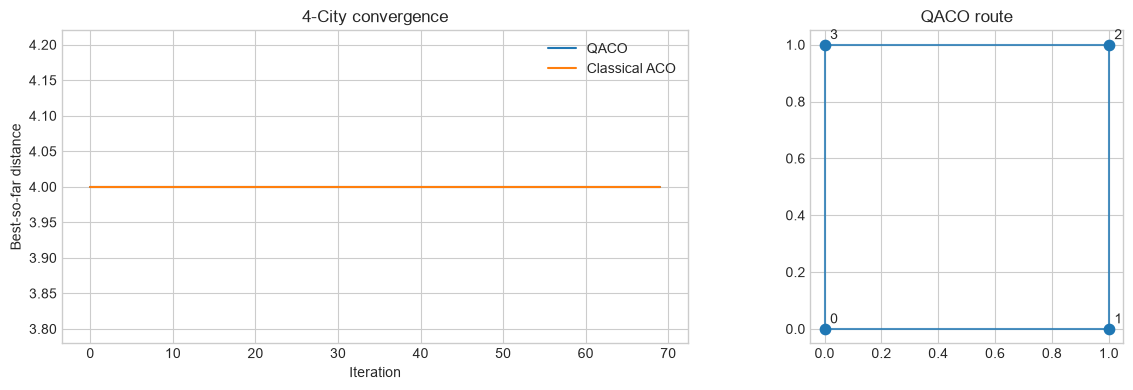

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].plot(qaco_4["convergence"], label="QACO")
axes[0].plot(aco_4["convergence"], label="Classical ACO")
axes[0].set(title="4-City convergence", xlabel="Iteration", ylabel="Best-so-far distance"); axes[0].legend()
plot_route(coords_4, qaco_4["route"], "QACO route", axes[1])
plt.tight_layout(); plt.show()

## 21. Qubit Requirement Calculation

**EXACT FROM PAPER (four cities):** 1 ancilla + 8 path bits = 9 qubits. The capacity calculation generalizes this relation as `ancilla + n*ceil(log2(n))`; this is an **Implementation Assumption** for arbitrary cluster sizes. With nine available qubits, the largest feasible city count is four.

In [20]:
def required_qubits(n_cities, ancilla_qubits=1): return ancilla_qubits + n_cities * bits_per_city(n_cities)
def maximum_cities_for_qubits(available_qubits, ancilla_qubits=1, upper=200):
    valid = [n for n in range(1, upper+1) if required_qubits(n, ancilla_qubits) <= available_qubits]
    return max(valid)
max_cluster_size = maximum_cities_for_qubits(CONFIG["available_qubits"], CONFIG["ancilla_qubits"])
assert required_qubits(4) == 9 and max_cluster_size == 4
print(f"Available qubits: {CONFIG['available_qubits']}; max cities/subproblem: {max_cluster_size}; required for 4: {required_qubits(4)}")

Available qubits: 9; max cities/subproblem: 4; required for 4: 9


## 22. Capacity-Constrained K-means

The paper directs K-means grouping relative to qubit capacity but gives no capacity-constrained assignment or rebalance rule. **IMPLEMENTATION ASSUMPTION — CAPACITY-CONSTRAINED K-MEANS:** deterministic farthest-first initial centers, nearest feasible-centroid assignment, followed by reassignment from oversized groups to nearest groups with room. It guarantees capacity rather than silently relying on unconstrained K-means.

In [21]:
def capacity_constrained_kmeans(coords, capacity, rng):
    X = np.asarray(coords, float); n = len(X); k = math.ceil(n / capacity)
    # deterministic random first center + farthest-first remaining centers
    centers = [X[int(rng.integers(n))]]
    while len(centers) < k:
        dmin = np.min([[np.linalg.norm(x-c) for c in centers] for x in X], axis=1)
        centers.append(X[int(np.argmax(dmin))])
    centers = np.asarray(centers)
    clusters = [[] for _ in range(k)]
    # Assign points in decreasing distance-from-nearest order, selecting nearest nonfull cluster.
    order = sorted(range(n), key=lambda i: np.min(np.linalg.norm(centers-X[i], axis=1)), reverse=True)
    for i in order:
        ranked = np.argsort(np.linalg.norm(centers-X[i], axis=1))
        c = next(int(j) for j in ranked if len(clusters[int(j)]) < capacity)
        clusters[c].append(i)
    # Lloyd centroid refinements while preserving cap through capacity-aware reassignment.
    for _ in range(12):
        centers = np.array([X[g].mean(axis=0) if g else centers[j] for j,g in enumerate(clusters)])
        new = [[] for _ in range(k)]
        for i in order:
            ranked = np.argsort(np.linalg.norm(centers-X[i], axis=1))
            c = next(int(j) for j in ranked if len(new[int(j)]) < capacity)
            new[c].append(i)
        if sorted(map(sorted,new)) == sorted(map(sorted,clusters)): break
        clusters = new
    clusters = [sorted(g) for g in clusters if g]
    assert max(map(len, clusters)) <= capacity
    assert sorted(sum(clusters, [])) == list(range(n))
    return clusters

clusters_16 = capacity_constrained_kmeans(coords_16, max_cluster_size, np.random.default_rng(SEED+3))
cluster_sizes = [len(c) for c in clusters_16]
assert max(cluster_sizes) <= max_cluster_size
cluster_table = pd.DataFrame({"Cluster ID": range(len(clusters_16)), "Cities": clusters_16, "Size": cluster_sizes,
                              "Required qubits": [required_qubits(s) for s in cluster_sizes]})
display(cluster_table)
print("Number of clusters:", len(clusters_16), " maximum cluster size:", max(cluster_sizes))

Table(columns=None, rows={'Cluster ID': range(0, 4), 'Cities': [[8, 9, 12, 13], [2, 3, 6, 7], [0, 1, 4, 5], [10, 11, 14, 15]], 'Size': [4, 4, 4, 4], 'Required qubits': [9, 9, 9, 9]})

Number of clusters: 4  maximum cluster size: 4


## 23. 16-City Hybrid QACO

Each capacity-compliant cluster is turned into a local TSP whose first listed city is its local depot, then solved by QACO. This implements the paper’s K-means → smaller QACO subproblems concept. Mapping local-to-global city labels and choosing a local depot are **Implementation Assumptions** necessitated by the lack of hybrid pseudocode.

In [22]:
def solve_cluster_qaco(cluster, global_D, seed):
    if len(cluster) == 1:
        city = cluster[0]; return {"route": [city, city], "distance": 0.0, "convergence": [0.0], "diagnostics": {}}
    subD = global_D[np.ix_(cluster, cluster)]
    local = qaco_tsp(subD, CONFIG["qaco_iterations_cluster"], np.random.default_rng(seed), label=f"Cluster {cluster}")
    mapped = [cluster[i] for i in local["route"]]
    return {**local, "route": mapped, "distance": route_distance(mapped, global_D)}

cluster_results = [solve_cluster_qaco(c, D_16, SEED+100+i) for i,c in enumerate(clusters_16)]
cluster_result_table = pd.DataFrame([{
    "Cluster": i, "Cities": clusters_16[i], "Size": len(clusters_16[i]), "QACO route": r["route"],
    "Cluster distance": r["distance"], "Feasible local": len(set(r["route"][:-1])) == len(clusters_16[i]),
    "Required qubits": required_qubits(len(clusters_16[i]))
} for i,r in enumerate(cluster_results)])
display(cluster_result_table.round({"Cluster distance":3}))
assert all(required_qubits(len(c)) <= CONFIG["available_qubits"] for c in clusters_16)

Table(columns=None, rows=[{'Cluster': 0, 'Cities': [8, 9, 12, 13], 'Size': 4, 'QACO route': [8, 12, 13, 9, 8], 'Cluster distance': 4.671266554617532, 'Feasible local': True, 'Required qubits': 9}, {'Cluster': 1, 'Cities': [2, 3, 6, 7], 'Size': 4, 'QACO route': [2, 6, 7, 3, 2], 'Cluster distance': 4.558549855407326, 'Feasible local': True, 'Required qubits': 9}, {'Cluster': 2, 'Cities': [0, 1, 4, 5], 'Size': 4, 'QACO route': [0, 4, 5, 1, 0], 'Cluster distance': 4.363879129517909, 'Feasible local': True, 'Required qubits': 9}, {'Cluster': 3, 'Cities': [10, 11, 14, 15], 'Size': 4, 'QACO route': [10, 14, 15, 11, 10], 'Cluster distance': 4.487585970132058, 'Feasible local': True, 'Required qubits': 9}])

## 24. Cluster-Level Results

Cluster size, local route, distance, feasibility, and qubits were printed above. The following diagnostics aggregate the paper-inspired quantum process without conflating these generated values with the paper benchmarks.

In [23]:
cluster_diagnostics = pd.DataFrame([{
    "Cluster": i, "feasible samples": r.get("diagnostics",{}).get("feasible_candidates", 0),
    "infeasible samples": r.get("diagnostics",{}).get("infeasible_candidates", 0),
    "random repairs": r.get("diagnostics",{}).get("random_repairs", 0),
    "Hamming repairs": r.get("diagnostics",{}).get("hamming_repairs", 0),
    "mutation activations": len(r.get("diagnostics",{}).get("mutation_activations", []))
} for i,r in enumerate(cluster_results)])
display(cluster_diagnostics)

Table(columns=None, rows=[{'Cluster': 0, 'feasible samples': 34, 'infeasible samples': 866, 'random repairs': 195, 'Hamming repairs': 671, 'mutation activations': 3}, {'Cluster': 1, 'feasible samples': 22, 'infeasible samples': 878, 'random repairs': 198, 'Hamming repairs': 680, 'mutation activations': 3}, {'Cluster': 2, 'feasible samples': 30, 'infeasible samples': 870, 'random repairs': 192, 'Hamming repairs': 678, 'mutation activations': 3}, {'Cluster': 3, 'feasible samples': 32, 'infeasible samples': 868, 'random repairs': 193, 'Hamming repairs': 675, 'mutation activations': 3}])

## 25. Global Route Stitching

**IMPLEMENTATION ASSUMPTION — GLOBAL ROUTE STITCHING:** the paper does not uniquely specify how cluster tours are joined. We greedily select the next cluster by nearest centroid from the current city, then choose the orientation and rotation of its local QACO cycle that minimizes the entering edge. The final closure returns to city 0. This reports intra-cluster and inter-cluster costs separately and does not claim to reproduce the paper’s hidden procedure.

In [24]:
def rotate_cycle(route, entry):
    core = route[:-1]; i = core.index(entry); rotated = core[i:] + core[:i]; return rotated + [rotated[0]]
def cycle_variants(route):
    core = route[:-1]; variants=[]
    for orientation in (core, list(reversed(core))):
        for city in orientation: variants.append(rotate_cycle(orientation+[orientation[0]], city))
    return variants
def stitch_cluster_routes(cluster_results, coords, start_city=0):
    D_local = euclidean_distance_matrix(coords)
    remaining = list(range(len(cluster_results))); current = start_city
    start_idx = next(i for i,r in enumerate(cluster_results) if start_city in r["route"][:-1])
    order=[start_idx]; remaining.remove(start_idx)
    while remaining:
        ci = min(remaining, key=lambda j: np.linalg.norm(coords[current]-np.mean(coords[cluster_results[j]["route"][:-1]], axis=0)))
        order.append(ci); remaining.remove(ci); current = cluster_results[ci]["route"][0]
    current = start_city; core=[]; selected=[]; intra=0.0; inter=0.0
    for ci in order:
        variants = cycle_variants(cluster_results[ci]["route"])
        candidate = min(variants, key=lambda r: D_local[current, r[0]])
        if core: inter += D_local[current, candidate[0]]
        # first candidate starts at city 0; its initial connection is therefore zero.
        intra += sum(D_local[candidate[i], candidate[i+1]] for i in range(len(candidate)-2))
        core.extend(candidate[:-1]); current = candidate[-2]; selected.append((ci, candidate))
    inter += D_local[current, start_city]
    route = core + [start_city]
    total = route_distance(route, D_local)
    assert abs(total - (intra + inter)) < 1e-9
    return route, order, intra, inter, total

hybrid_route_16, cluster_order_16, intra_cluster_cost_16, inter_cluster_cost_16, hybrid_distance_16 = stitch_cluster_routes(cluster_results, coords_16)
within_block_cost_16 = intra_cluster_cost_16
print("Cluster order:", cluster_order_16)
print(f"Intra-cluster traversed cost: {intra_cluster_cost_16:.3f}; inter-cluster connection cost: {inter_cluster_cost_16:.3f}; stitched total: {hybrid_distance_16:.3f}")

Cluster order: [2, 1, 3, 0]
Intra-cluster traversed cost: 13.532; inter-cluster connection cost: 9.016; stitched total: 22.547


## 26. Final Route Validation

The dedicated validator checks start/end depot, unique coverage, no duplication, and a correctly finite distance. Because a stitched tour replaces each cluster’s closing edge with inter-cluster edges, “intra-cluster cost” is reported separately from the final route cost.

In [25]:
hybrid_distance_16 = validate_tour(hybrid_route_16, D_16, start_city=0)
assert hybrid_route_16[0] == 0 and hybrid_route_16[-1] == 0
assert len(set(hybrid_route_16[:-1])) == len(coords_16)
print("Final hybrid route:", hybrid_route_16)
print("Final route feasible:", is_valid_tour(hybrid_route_16, len(coords_16)))
print("Final distance:", hybrid_distance_16)

Final hybrid route: [0, 4, 5, 1, 2, 6, 7, 3, 11, 10, 14, 15, 13, 9, 8, 12, 0]
Final route feasible: True
Final distance: 22.54739894543868


## 27. ACO vs Hybrid QACO Comparison

The same 16-city coordinates and distance matrix are used. This comparison honestly reports the generated result; no parameter tuning is performed to favor QACO.

Table(columns=['Method', 'Route', 'Distance', 'Feasible'], rows=[['Hybrid QACO', [0, 4, 5, 1, 2, 6, 7, 3, 11, 10, 14, 15, 13, 9, 8, 12, 0], 22.54739894543868, 'Yes'], ['Classical ACO', [0, 1, 2, 3, 7, 11, 15, 14, 13, 12, 9, 10, 6, 5, 4, 8, 0], 19.566077306500755, 'Yes']])

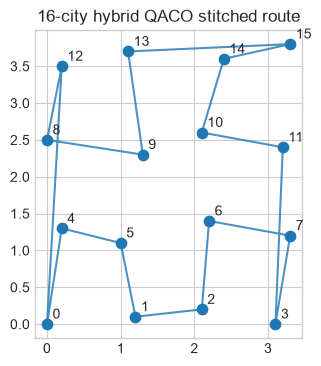

In [26]:
aco_16 = aco_tsp(D_16, CONFIG["aco_iterations_16city"], np.random.default_rng(SEED+4))
comparison_16 = pd.DataFrame([
    ["Hybrid QACO", hybrid_route_16, hybrid_distance_16, "Yes" if is_valid_tour(hybrid_route_16,16) else "No"],
    ["Classical ACO", aco_16["route"], aco_16["distance"], "Yes" if is_valid_tour(aco_16["route"],16) else "No"],
], columns=["Method", "Route", "Distance", "Feasible"])
display(comparison_16.round({"Distance":3}))
fig, ax = plt.subplots(figsize=(6,4)); plot_route(coords_16, hybrid_route_16, "16-city hybrid QACO stitched route", ax); plt.show()

## 28. Diagnostic Analysis

These execution-derived diagnostics cover convergence, stagnation/mutation, feasibility, repairs, Hamming selection, best updates, cluster resources, and final validity. A QACO result worse than ACO is a result, not a failure concealed by the notebook.

4-city QACO diagnostics:
  feasible_candidates: 59
  infeasible_candidates: 1341
  random_repairs: 197
  hamming_repairs: 1144
  mutation_activations: [(6, 5, 0.5235987755982988, 0.06698729810778066), (11, 10, 0.7853981633974483, 0.14644660940672624), (16, 15, 1.5707963267948966, 0.5000000000000001)]
  best_updates: 1
  last_hamming_distances: [3.0, 3.0, 5.0]
  last_hamming_probabilities: [0.3846153846153846, 0.3846153846153846, 0.23076923076923078]

4-city global-best updates: 1
16-city cluster sizes: [4, 4, 4, 4]
Qubit utilization by cluster: ['9/9', '9/9', '9/9', '9/9']
Intra-cluster traversed cost: 13.532
Inter-cluster connection cost: 9.016
Stitched final route cost: 22.547
Final route feasible: True


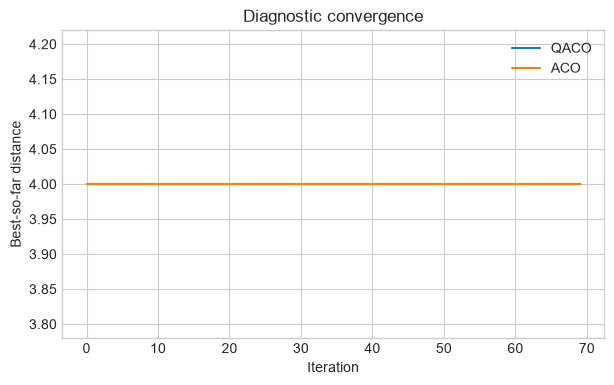

In [27]:
qdiag = qaco_4["diagnostics"]
print("4-city QACO diagnostics:")
for k,v in qdiag.items(): print(f"  {k}: {v}")
print("\n4-city global-best updates:", qaco_4["diagnostics"]["best_updates"])
print("16-city cluster sizes:", cluster_sizes)
print("Qubit utilization by cluster:", [f"{required_qubits(len(c))}/{CONFIG['available_qubits']}" for c in clusters_16])
print(f"Intra-cluster traversed cost: {intra_cluster_cost_16:.3f}")
print(f"Inter-cluster connection cost: {inter_cluster_cost_16:.3f}")
print(f"Stitched final route cost: {hybrid_distance_16:.3f}")
print("Final route feasible:", is_valid_tour(hybrid_route_16, 16))
fig, ax = plt.subplots(figsize=(7,4)); ax.plot(qaco_4["convergence"], label="QACO"); ax.plot(aco_4["convergence"], label="ACO"); ax.set(xlabel="Iteration", ylabel="Best-so-far distance", title="Diagnostic convergence"); ax.legend(); plt.show()

## 29. Paper-vs-Implementation Assumptions

The table separates reproducible direct statements from necessary reconstructions. **PAPER-REPORTED RESULTS** are intentionally separate: Ulysses-16: ACO 69.67, QACO 62.14; Bayg-29: ACO 25089.08, QACO 12545.95; random 64-point: ACO 331187.30, QACO 148170.56. Their coordinates and full execution configuration are absent, so this notebook does not label its values as a replication.

In [28]:
assumptions = pd.DataFrame([
["9-qubit 4-city encoding", "1 ancilla + 8 path qubits; 2 bits/city", "Implemented exactly", "EXACT FROM PAPER"],
["Initial path state", "rotation angle π/2", "Ry angle π/2 per path bit", "EXACT FROM PAPER"],
["Rotation table", "Table 2 eight cases", "Visible direct lookup table", "EXACT FROM PAPER"],
["Infeasible solutions", "random first 10; inverse Hamming pool later", "Implemented with normalized safe weights", "RECONSTRUCTED"],
["Mutation", "5/10/15 => π/6/π/4/π/2; >15 zero", "Ancilla-conditioned bit flip", "RECONSTRUCTED"],
["Quantum gate sequence", "Figure 2 not unambiguous", "Independent Ry sampling + ancilla control", "IMPLEMENTATION ASSUMPTION"],
["Quantum simulator", "Yiwei platform", "NumPy backend; optional Qiskit circuit", "IMPLEMENTATION ASSUMPTION"],
["Binary generalization", "Only 4-city, two-bit stated", "ceil(log2(n)) bits/city", "IMPLEMENTATION ASSUMPTION"],
["Invalid states", "Examination module stated", "strict decode, safe repair", "IMPLEMENTATION ASSUMPTION"],
["Capacity clustering", "K relative to qubits", "capacity-aware K-means/rebalance", "IMPLEMENTATION ASSUMPTION"],
["Global stitching", "not specified", "greedy centroid/order/orientation stitch", "IMPLEMENTATION ASSUMPTION"],
["Datasets/parameters", "Names/results but no coordinates/full settings", "explicit synthetic coords; config disclosed", "NOT SPECIFIED BY PAPER"],
], columns=["Component","Paper specification","Our implementation","Status"])
display(assumptions)
paper_reported = pd.DataFrame([["Ulysses-16",69.67,62.14,None,None],["Bayg-29",25089.08,12545.95,None,None],["Random 64-point",331187.30,148170.56,None,None]], columns=["Dataset","Paper ACO","Paper QACO","Our ACO","Our QACO"])
display(paper_reported)

Table(columns=['Component', 'Paper specification', 'Our implementation', 'Status'], rows=[['9-qubit 4-city encoding', '1 ancilla + 8 path qubits; 2 bits/city', 'Implemented exactly', 'EXACT FROM PAPER'], ['Initial path state', 'rotation angle π/2', 'Ry angle π/2 per path bit', 'EXACT FROM PAPER'], ['Rotation table', 'Table 2 eight cases', 'Visible direct lookup table', 'EXACT FROM PAPER'], ['Infeasible solutions', 'random first 10; inverse Hamming pool later', 'Implemented with normalized safe weights', 'RECONSTRUCTED'], ['Mutation', '5/10/15 => π/6/π/4/π/2; >15 zero', 'Ancilla-conditioned bit flip', 'RECONSTRUCTED'], ['Quantum gate sequence', 'Figure 2 not unambiguous', 'Independent Ry sampling + ancilla control', 'IMPLEMENTATION ASSUMPTION'], ['Quantum simulator', 'Yiwei platform', 'NumPy backend; optional Qiskit circuit', 'IMPLEMENTATION ASSUMPTION'], ['Binary generalization', 'Only 4-city, two-bit stated', 'ceil(log2(n)) bits/city', 'IMPLEMENTATION ASSUMPTION'], ['Invalid states', 

Table(columns=['Dataset', 'Paper ACO', 'Paper QACO', 'Our ACO', 'Our QACO'], rows=[['Ulysses-16', 69.67, 62.14, None, None], ['Bayg-29', 25089.08, 12545.95, None, None], ['Random 64-point', 331187.3, 148170.56, None, None]])

## 30. Final Experimental Summary

The final cell below automatically reports values generated during this run, together with the paper/implementation boundary.

In [29]:
improvement_gap_16 = 100 * (hybrid_distance_16 - aco_16["distance"]) / aco_16["distance"]
print("=" * 60)
print("QACO EXPERIMENT SUMMARY")
print("=" * 60)
print("\n## 4-City Problem")
print(f"Exact optimum: {exact_distance_4:.6f} | route {exact_route_4}")
print(f"QACO: {qaco_4['distance']:.6f} | route {qaco_4['route']}")
print(f"ACO: {aco_4['distance']:.6f} | route {aco_4['route']}")
print(f"QACO optimality gap: {optimality_gap(qaco_4['distance'], exact_distance_4):.2f}%")
print(f"ACO optimality gap: {optimality_gap(aco_4['distance'], exact_distance_4):.2f}%")
print("\n## 16-City Problem")
print(f"Number of cities: {len(coords_16)}")
print(f"Available qubits: {CONFIG['available_qubits']}")
print(f"Maximum cities per quantum subproblem: {max_cluster_size}")
print(f"Number of clusters: {len(clusters_16)}")
print(f"Cluster sizes: {cluster_sizes}")
print(f"Hybrid QACO distance: {hybrid_distance_16:.6f}")
print(f"Hybrid QACO feasible: {is_valid_tour(hybrid_route_16, len(coords_16))}")
print(f"ACO distance: {aco_16['distance']:.6f}")
print(f"Improvement / Gap (Hybrid QACO vs ACO): {improvement_gap_16:+.2f}%")
print("\n" + "=" * 60)
print("IMPLEMENTATION VALIDITY")
print("=" * 60)
print("Exact paper components: 9-qubit 4-city encoding, pi/2 initialization, Table-2 rotation lookup, 10-iteration random repair rule, Hamming-pool rule, mutation thresholds.")
print("Implementation assumptions: gate topology/simulator backend, arbitrary-size encoding, safe invalid-state policy, capacity-aware clustering, local depots, and global stitching.")
print("Known limitations: Figure 2 and full Yiwei settings are not sufficient for exact circuit reproduction; paper benchmark coordinates are unavailable; hybrid stitching is not a paper-specified method.")
print("=" * 60)

QACO EXPERIMENT SUMMARY

## 4-City Problem
Exact optimum: 4.000000 | route [0, 1, 2, 3, 0]
QACO: 4.000000 | route [0, 3, 2, 1, 0]
ACO: 4.000000 | route [0, 1, 2, 3, 0]
QACO optimality gap: 0.00%
ACO optimality gap: 0.00%

## 16-City Problem
Number of cities: 16
Available qubits: 9
Maximum cities per quantum subproblem: 4
Number of clusters: 4
Cluster sizes: [4, 4, 4, 4]
Hybrid QACO distance: 22.547399
Hybrid QACO feasible: True
ACO distance: 19.566077
Improvement / Gap (Hybrid QACO vs ACO): +15.24%

IMPLEMENTATION VALIDITY
Exact paper components: 9-qubit 4-city encoding, pi/2 initialization, Table-2 rotation lookup, 10-iteration random repair rule, Hamming-pool rule, mutation thresholds.
Implementation assumptions: gate topology/simulator backend, arbitrary-size encoding, safe invalid-state policy, capacity-aware clustering, local depots, and global stitching.
Known limitations: Figure 2 and full Yiwei settings are not sufficient for exact circuit reproduction; paper benchmark coordina